In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [ ]:
df=pd.read_csv('fetal_health.csv')
print(df.shape)
print(df)

In [21]:
x=df.drop('fetal_health', axis=1)
y=df['fetal_health']


In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2 )

In [23]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaler.fit(x_train)
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [25]:
from sklearn.neighbors import KNeighborsClassifier
 
model=KNeighborsClassifier(n_neighbors=47)
model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=47)

In [26]:
y_pred=model.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[331   6   0]
 [ 26  27   1]
 [  6   7  22]]
              precision    recall  f1-score   support

         1.0       0.91      0.98      0.95       337
         2.0       0.68      0.50      0.57        54
         3.0       0.96      0.63      0.76        35

    accuracy                           0.89       426
   macro avg       0.85      0.70      0.76       426
weighted avg       0.89      0.89      0.88       426



In [27]:
error=[]
for i in range(1, 50):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    y_predi=knn.predict(x_test)
    error.append(np.mean(y_predi != y_test))

Text(0, 0.5, 'Mean Error')

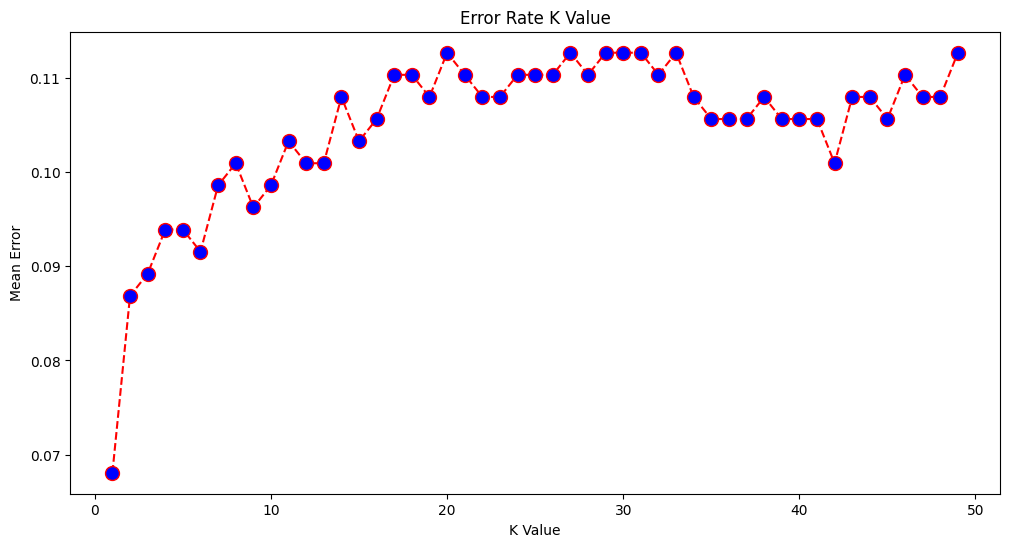

In [28]:
plt.figure(figsize=(12,6))
plt.plot(range(1,50), error, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.title("Error Rate K Value")
plt.xlabel("K Value")
plt.ylabel("Mean Error")

In [31]:
model1=KNeighborsClassifier(n_neighbors=5)
model1.fit(x_train, y_train)
y_pred=model1.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test , y_pred))

[[328   9   0]
 [ 20  31   3]
 [  4   4  27]]
              precision    recall  f1-score   support

         1.0       0.93      0.97      0.95       337
         2.0       0.70      0.57      0.63        54
         3.0       0.90      0.77      0.83        35

    accuracy                           0.91       426
   macro avg       0.85      0.77      0.81       426
weighted avg       0.90      0.91      0.90       426

